# Machine Trading — Chapter 3 Time Series Analysis

이 노트북은 Chapter 3의 AR, ARMA/ARIMA, VAR/VEC, 상태공간·Kalman 예제를
공식 지원 ZIP 데이터로 실행한다. 목표는 높은 수익률을 전시하는 것이 아니라
책의 식이 어떤 코드와 시차로 연결되는지, 원본 소스에 누수가 있는지, 체결비용을
넣으면 결론이 유지되는지를 감사 가능한 형태로 남기는 것이다.

학습 질문은 다음과 같다.

1. 가격수준의 AR 계수가 1에 가깝다는 사실은 어떤 위험을 뜻하는가?
2. BIC가 선택한 AR(10)의 책 수치는 train-only 결과인가?
3. ARMA의 MA 항은 MATLAB의 one-step `forecast`에서 어떻게 처리되는가?
4. VAR과 VEC의 행렬 관계는 어떻게 검증하는가?
5. Kalman filter의 예측 상태와 갱신 상태 중 어느 것을 거래 신호로 써야 하는가?
6. midprice 성과가 bid/ask 체결비용 뒤에도 살아남는가?

여기서 ‘수치 재현’, ‘published-parameter replay’, ‘방법론적 적응’, ‘데이터 부재’를
구분한다. 모든 곡선이 진짜 투자 가능한 백테스트라는 뜻은 아니다.

## 1. Chapter coverage / 재현 상태

| 주제 | 상태 | 핵심 증거 |
|---|---|---|
| AR(1), 정상성, random walk | 수치 재현 | AUD·BTC 원본 계수 비교 |
| bid-ask bounce | 실행 진단 | midprice gross와 관측 spread net |
| AR(p), BIC, Table 3.1 | 수치 재현 | p=10, 계수 5e-6 이내 |
| Figure 3.1 AR(10) | 원본 재현 + 수정 | full-sample 누수와 train-only 분리 |
| ARMA(2,5), Table 3.2 | 계수 replay | MATLAB zero-future-innovation 의미 |
| ARIMA(1,1,9) | 수식·source-output | 차분 가격과 수익률 연결 |
| VAR(1), sector neutral | 방법론적 적응 | 공식 close, 마지막 252일 OOS |
| VEC | identity 실행 | C = Φ − I |
| hardware Kalman | 계수 적응 | 책 noise를 다른 close 기간에 적용 |
| EWA–EWC Kalman | 계수 replay | Table 3.6 B,D와 1250/250 split |
| HP/wavelet·regime change | 개념 설명 | 입력·모형 한계 |
| 연습문제 3.1–3.8 | 선택 실행·매핑 | 비용, BIC, VAR/VEC, Kalman |

책의 hardware 예제가 요구하는 CRSP bid/ask와 Compustat 산업분류는 ZIP에 없으므로
close 적응을 책 수치의 정확 재현이라고 부르지 않는다.

## 2. 수식에서 코드로 / formula-to-code

$$P_t=\phi_0+\sum_{i=1}^{p}\phi_iP_{t-i}+\epsilon_t$$

$$y_t=a+\Phi_1y_{t-1}+\cdots+\Phi_py_{t-p}+\epsilon_t$$

$$x_t=Ax_{t-1}+Bu_t,\qquad y_t=C_tx_t+De_t$$

| 수식 단계 | 구현 함수 | 시차 계약 |
|---|---|---|
| 조건부 AR OLS | `fit_ar_conditional` | `end` 이전 자료만 적합 가능 |
| AR/ARMA 예측 | `forecast_ar`, `forecast_arma_zero_innovations` | t까지 보고 t+1 예측 |
| VAR OLS·BIC | `fit_var_coefficients` | 마지막 252일 이전 적합 |
| sector neutral | `normalized_sector_positions` | 같은 날 예측 평균 제거 |
| random-walk state | `kalman_hardware_adaptation` | prediction 후 observation update |
| 동적 hedge state | `kalman_pair_replay` | forecast error ±1σ로 상태 전환 |
| P&L | `trade_intraday_forecast`, `daily_panel_strategy` | position[t]는 return[t+1]에 적용 |

random_seed = None이다. 난수 기반 최적화는 없고, published coefficients와
결정론적 NumPy 선형대수만 사용한다.

In [1]:
from io import BytesIO
from pathlib import Path
import sys
from IPython.display import Image, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("project root not found")

PROJECT_ROOT = find_project_root()
SRC = PROJECT_ROOT / "chapter_3_time_series_analysis/src"
sys.path.insert(0, str(SRC))
from run_chapter3_analysis import (
    AUDIT_SCRIPT_PATH, BOOK_RESULTS, CHAPTER_COVERAGE, NOTEBOOK_PATH,
    PYPROJECT_PATH, UV_LOCK_PATH, chapter_manifest, create_ar_diagnostics_figure,
    create_model_map_figure, create_multivariate_figure, create_pair_figure,
    environment_versions, load_chapter_data, run_experiments, sha256_file,
    validate_offline_assets, verification_summary, verify_results,
)

def show_figure(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    plt.close(figure)
    display(Image(data=buffer.getvalue()))

validate_offline_assets()
print("offline archive and all extracted members: checksum verified")

offline archive and all extracted members: checksum verified


## 3. Provenance와 잠금 환경

공식 페이지 URL, 직접 ZIP URL, ZIP SHA-256, `SOURCE_MANIFEST.json`의 각 멤버
SHA-256, `uv.lock` SHA-256을 함께 기록한다. URL만 남기면 공급자가 파일을 조용히
교체했을 때 같은 이름의 다른 데이터로 실행될 수 있다. 실제로 이 장의 ZIP은
다운로드 후 계산한 해시를 manifest에 고정했으며 offline 실행은 네트워크 없이
모든 파일을 재검증한다.

In [2]:
manifest = chapter_manifest()
provenance = pd.Series({
    "source_page": manifest["source_page"],
    "archive_url": manifest["url"],
    "archive_sha256": manifest["sha256"],
    "uv_lock_sha256": sha256_file(UV_LOCK_PATH),
})
display(provenance.to_frame("value"))
display(pd.Series(environment_versions()).to_frame("environment version"))

,value
source_page,https://epchan.com/book3
archive_url,https://epchan.com/img/book3/Chap3%20Time%20Se...
archive_sha256,a91e58b6d044e3bedc9bf4df32fbf6d6bae61db9943b15...
uv_lock_sha256,d3b494323b4b7b207e1f32e4f86e1c42e24d90afc8b86e...


,environment version
python,3.12.3
numpy,2.5.1
pandas,3.0.3
scipy,1.18.0
matplotlib,3.11.1
nbformat,5.10.4
nbclient,0.11.0


## 4. 데이터 구조와 결측 진단

AUD.USD 분봉은 파일 앞부분의 NaN만 잘라내고 내부 결측은 허용하지 않는다.
마지막 359,100분봉은 252거래일 × 하루 1,425분으로 정의한 테스트다. BTC는
345일 가격, hardware는 공식 close 패널에서 결측 없는 다섯 종목, ETF는 EWA와
EWC를 선택한다. 서로 다른 빈도와 기간의 결과를 한 숫자로 합치지 않는다.

결측을 미래 관측값으로 채우면 look-ahead가 생기고, 비양수 가격은 수익률 분모를
망가뜨린다. 아래 진단이 0인지 먼저 확인한다.

In [3]:
data = load_chapter_data()
diagnostics = pd.Series({
    "AUD bars": len(data.aud_mid),
    "AUD train bars": data.aud_train_end,
    "AUD test bars": len(data.aud_mid) - data.aud_train_end,
    "AUD missing mid": int(np.count_nonzero(~np.isfinite(data.aud_mid))),
    "AUD nonpositive mid": int(np.count_nonzero(data.aud_mid <= 0)),
    "BTC daily observations": len(data.btc_close),
    "hardware rows": len(data.hardware_close),
    "hardware missing": int(np.count_nonzero(~np.isfinite(data.hardware_close))),
    "EWA/EWC rows": len(data.ewa),
})
display(diagnostics.to_frame("value"))
assert diagnostics[["AUD missing mid", "AUD nonpositive mid", "hardware missing"]].sum() == 0

,value
AUD bars,2963610
AUD train bars,2604510
AUD test bars,359100
AUD missing mid,0
AUD nonpositive mid,0
BTC daily observations,345
hardware rows,1500
hardware missing,0
EWA/EWC rows,1500


## 5. 모형에서 거래까지의 지도

단변량·다변량·잠재상태 모형은 모양이 달라도 거래 관점에서는 같은 경계를 지난다.
관측 가능한 시점까지 적합하고, 다음 관측을 예측하며, 예측 후에 포지션을 만들고,
그 다음 수익에 포지션을 적용해야 한다. 한 칸만 어긋나도 미래정보가 들어간다.

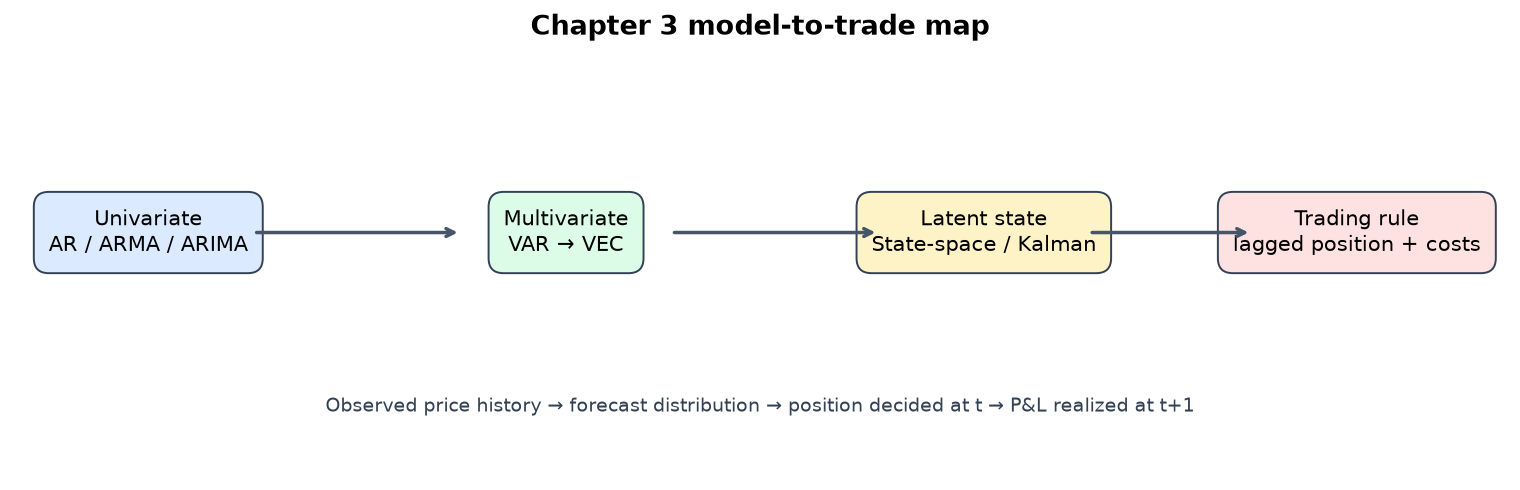

In [4]:
show_figure(create_model_map_figure())

## 6. 모든 실험 실행

다음 셀은 296만 분봉의 AR 충분통계, BIC 60개 후보, AR(10) 두 적합 창,
published ARMA, VAR/VEC, 두 Kalman 실험을 실행한다. 전체표본 AR(10)은 원본 수치
감사용이며 올바른 OOS 전략으로 승격시키지 않는다.

In [5]:
results = run_experiments(data)
print("selected AUD AR lag:", results["selected_ar_lag"])
print("experiments:", [k for k in ("ar10_full", "ar10_train", "arma25", "var", "hardware_kalman", "pair_kalman")])

selected AUD AR lag: 10
experiments: ['ar10_full', 'ar10_train', 'arma25', 'var', 'hardware_kalman', 'pair_kalman']


## 7. AR(1)과 정상성 해석

AUD와 BTC의 AR(1) 계수가 1에 매우 가깝다. 이는 가격수준 충격이 오래 지속됨을
뜻하며, 단순한 평균회귀 신호로 읽어서는 안 된다. 거래가격에서 관찰한 짧은 음의
자기상관은 spread bounce일 수 있으므로 mid, bid, ask를 분리해야 한다.

In [6]:
ar1 = pd.DataFrame({
    "Python phi1": [results["aud_ar1_coefficients"][1], results["btc_ar1_coefficients"][1]],
    "book/source phi1": [BOOK_RESULTS["aud_ar1_phi"], BOOK_RESULTS["btc_daily_ar1_phi"]],
}, index=["AUD.USD minute", "BTC.USD daily"])
display(ar1)
assert abs(ar1.iloc[0, 0] - ar1.iloc[0, 1]) <= 2e-6
assert abs(ar1.iloc[1, 0] - ar1.iloc[1, 1]) <= 0.003

,Python phi1,book/source phi1
AUD.USD minute,0.999998,0.999998
BTC.USD daily,0.988353,0.989484


## 8. AR(p), BIC와 원본 look-ahead

BIC는 p=10을 고른다. 책 결과를 만든 MATLAB은 `trainset`을 선언했지만
`estimate(model, mid)`로 전체 sample을 적합한다. 따라서 책의 158%는 미래 테스트
관측이 계수에 들어간 결과다. train-only 계수로 바꾸면 수익은 낮아지고, 이 차이는
반드시 별도 행으로 보고해야 한다.

In [7]:
comparison = pd.DataFrame({
    "annual return": [results[k].performance.annual_return for k in ("ar10_full", "ar10_train", "arma25")],
    "Sharpe": [results[k].performance.sharpe for k in ("ar10_full", "ar10_train", "arma25")],
    "spread/cost annual return": [results[k].cost_performance.annual_return for k in ("ar10_full", "ar10_train", "arma25")],
}, index=["AR10 full-fit (look-ahead)", "AR10 train-only", "ARMA25 replay"])
display(comparison)
assert results["selected_ar_lag"] == 10
assert abs(results["ar10_full"].performance.annual_return - BOOK_RESULTS["ar10_annual_return"]) <= 0.005
assert not np.allclose(results["ar10_full_coefficients"], results["ar10_train_coefficients"], atol=1e-7, rtol=0)

,annual return,Sharpe,spread/cost annual return
AR10 full-fit (look-ahead),1.583648,7.431102,-0.999608
AR10 train-only,1.402665,6.867399,-0.999670
ARMA25 replay,0.600793,3.715710,-1.000000


## 9. ARMA/ARIMA와 거래비용

ARMA(2,5)는 Table 3.2의 계수를 replay한다. MATLAB `forecast`에 과거 가격 Y0만
주고 E0를 생략한 one-step 예측은 미래 MA innovation을 0으로 둔다. 임의의 잔차
재귀를 더하면 책과 다른 전략이다. ARIMA(1,1,9)는 가격을 한 번 차분한 뒤
ARMA를 적용하는 표현이며, 차분 또는 로그수익이 단위근 가격수준보다 안정적이다.

midprice gross curve는 실행 가능성의 상한에 가깝다. 관측 half-spread × turnover를
차감하면 고빈도 신호가 거의 전부 사라진다. 슬리피지, latency, market impact까지
포함하지 않았으므로 net 결과도 낙관적일 수 있다.

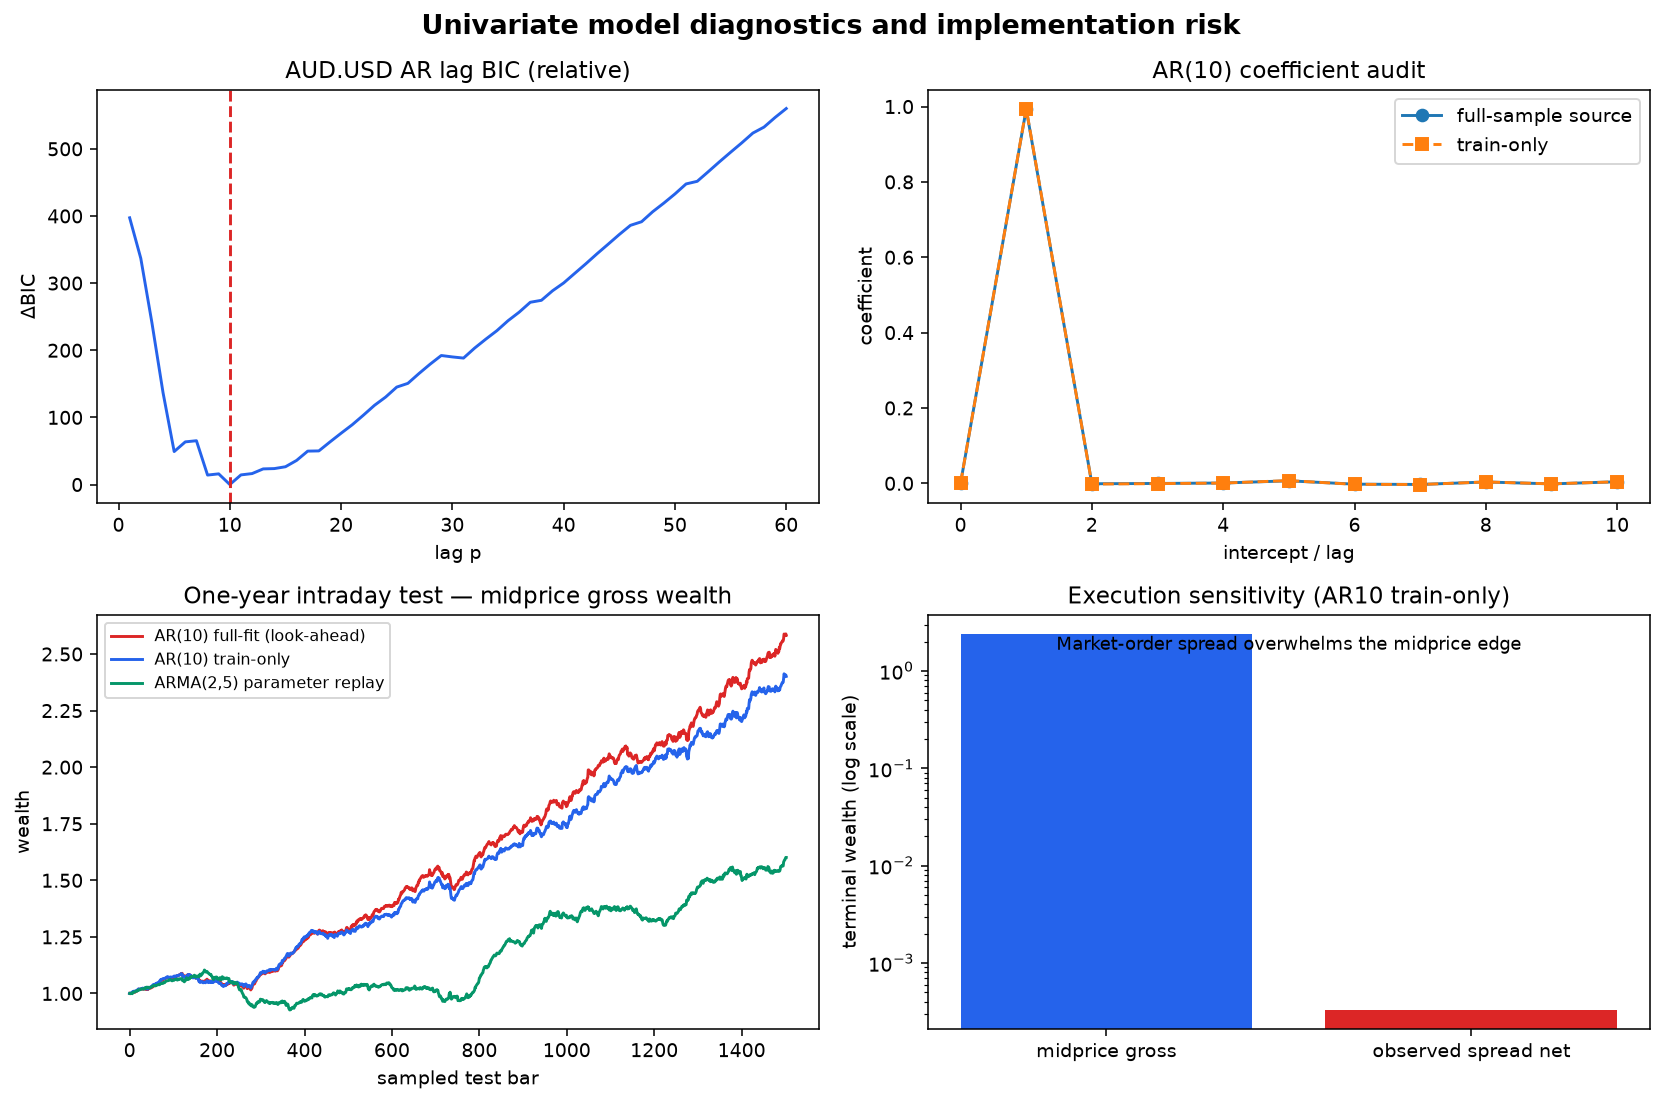

In [8]:
show_figure(create_ar_diagnostics_figure(data, results))

## 10. VAR(1)과 sector-neutral OOS

VAR은 다섯 가격의 lag를 동시에 사용한다. 공식 close 데이터의 마지막 252일을
완전히 남기고 이전 구간에서만 계수를 적합했다. 포지션은 예측수익에서 당일 섹터
평균을 빼 순합 0, 절대합 1로 정규화한다. 하지만 종목 수 중립은 beta·달러·산업
노출의 완전한 중립과 다르다.

책의 48%/Sharpe 0.9는 7개 CRSP midquote 및 Compustat 분류에서 나온다. 현재
공식 ZIP에는 그 입력이 없으므로 아래 결과는 방법론적 적응이며 직접 수치 비교는
금지한다.

In [9]:
var = results["var"]
var_table = pd.Series({
    "selected lag": var.metadata["lag"],
    "OOS annual return": var.performance.annual_return,
    "OOS Sharpe": var.performance.sharpe,
    "OOS maximum drawdown": var.performance.maximum_drawdown,
})
display(var_table.to_frame("value"))
active = np.sum(np.abs(var.positions), axis=1) > 0
assert np.allclose(var.positions[active].sum(axis=1), 0, atol=1e-12)

,value
selected lag,1.000000
OOS annual return,-0.049747
OOS Sharpe,-0.270699
OOS maximum drawdown,-0.206882


## 11. VEC identity와 공적분 주의

VAR(1)을 차분하면 C=Φ−I인 VEC 형태가 된다. 이 행렬 등식은 코드 계약으로
검증할 수 있지만, C의 대각이 음수라는 것만으로 공적분 rank가 정해지지는 않는다.
Johansen 검정의 lag와 deterministic term을 결과를 본 뒤 선택하면 data snooping이
생긴다. 관계가 과거에 안정적이었다는 사실도 regime change 뒤의 지속성을 보장하지
않는다.

,AAPL,EMC,HPQ,NTAP,SNDK
ΔAAPL,-0.006409,0.128409,-0.025633,0.030892,-0.022403
ΔEMC,0.000570,-0.010439,-0.001908,0.000377,0.001041
ΔHPQ,-0.000907,0.016905,-0.011486,0.003828,-0.003109
ΔNTAP,0.002080,-0.022384,-0.009465,-0.007805,0.004188
ΔSNDK,-0.000777,0.001635,0.002393,0.015050,-0.011630


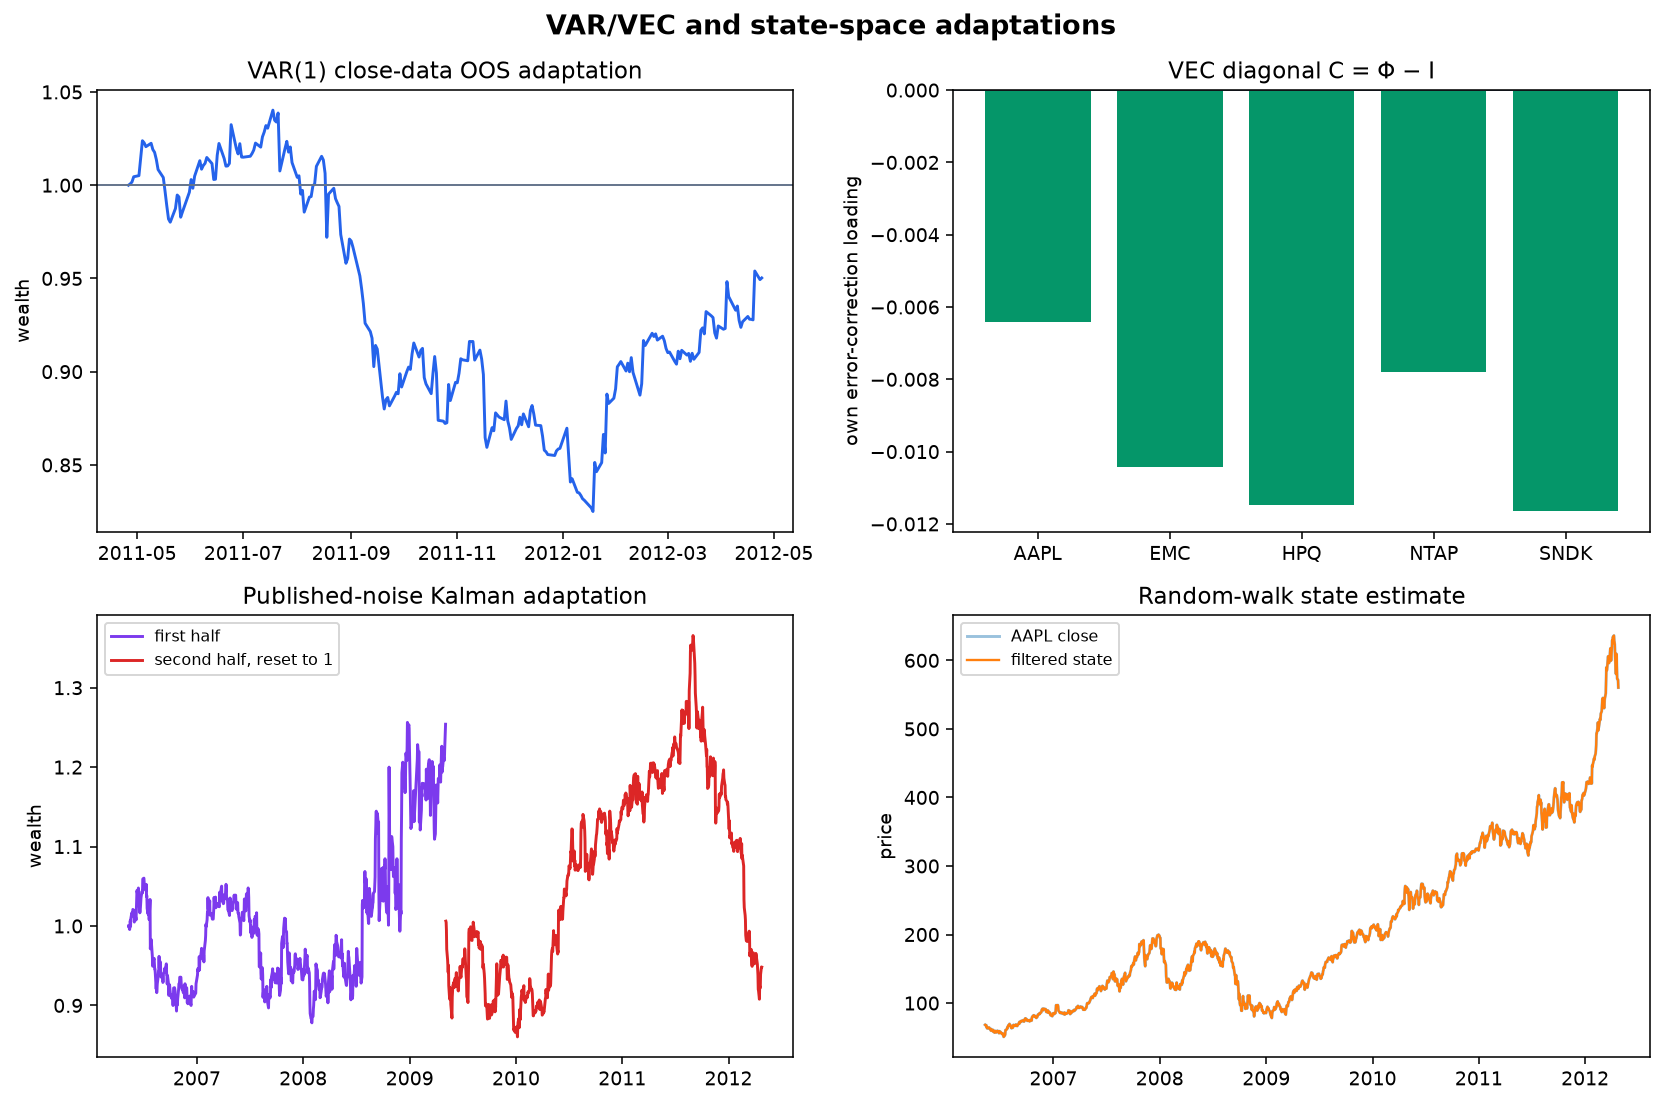

In [10]:
phi = results["var_details"]["phi"]
vec_c = results["var_details"]["vec_c"]
display(pd.DataFrame(vec_c, index=["Δ"+s for s in ("AAPL","EMC","HPQ","NTAP","SNDK")], columns=("AAPL","EMC","HPQ","NTAP","SNDK")))
assert np.allclose(vec_c, phi - np.eye(5))
show_figure(create_multivariate_figure(data, results))

## 12. 상태공간·Kalman hardware 적응

random-walk state는 어제의 filtered state를 오늘의 prediction으로 사용하고 오늘
가격을 본 뒤 update한다. updated state를 같은 날 예측으로 쓰면 미래관측을 섞는
오류다. Table 3.5의 noise loading을 고정해 공식 close 기간에 적용했으며 MATLAB
MLE를 다시 실행하지 않았다. 그래서 책 수치와 차이가 나도 published-parameter
methodological adaptation이라는 분류가 유지된다.

In [11]:
hardware = results["hardware_kalman"]
display(pd.DataFrame({
    "train replay": hardware.metadata["train_performance"],
    "second-half test": hardware.performance.__dict__,
}).loc[["annual_return", "sharpe", "maximum_drawdown"]])
print("mean absolute one-step forecast error / price:", results["hardware_details"]["mean_absolute_forecast_error_fraction"])

,train replay,second-half test
annual_return,0.079015,-0.017690
sharpe,0.430728,-0.033723
maximum_drawdown,-0.172185,-0.335255


mean absolute one-step forecast error / price: 0.018708854755416567


## 13. EWA–EWC 동적 hedge ratio

EWC 관측식의 기울기와 절편을 상태로 두고 Table 3.6의 B,D를 그대로 replay한다.
innovation이 ±1σ를 넘을 때만 long/short 상태를 바꾸며, 상태가 정한 dollar
positions는 하루 lag 뒤 P&L에 적용한다. 1250일 학습 replay 뒤 250일 테스트가
약해지는 현상은 공적분·hedge 관계의 regime change와 임계값 과적합 가능성을
경고한다. 이는 새로 최적화한 백테스트가 아니라 published-parameter replay다.

,train replay,test
annual_return,0.095712,-0.005262
sharpe,1.242420,-0.126714
maximum_drawdown,-0.092270,-0.046209


state changes: 578


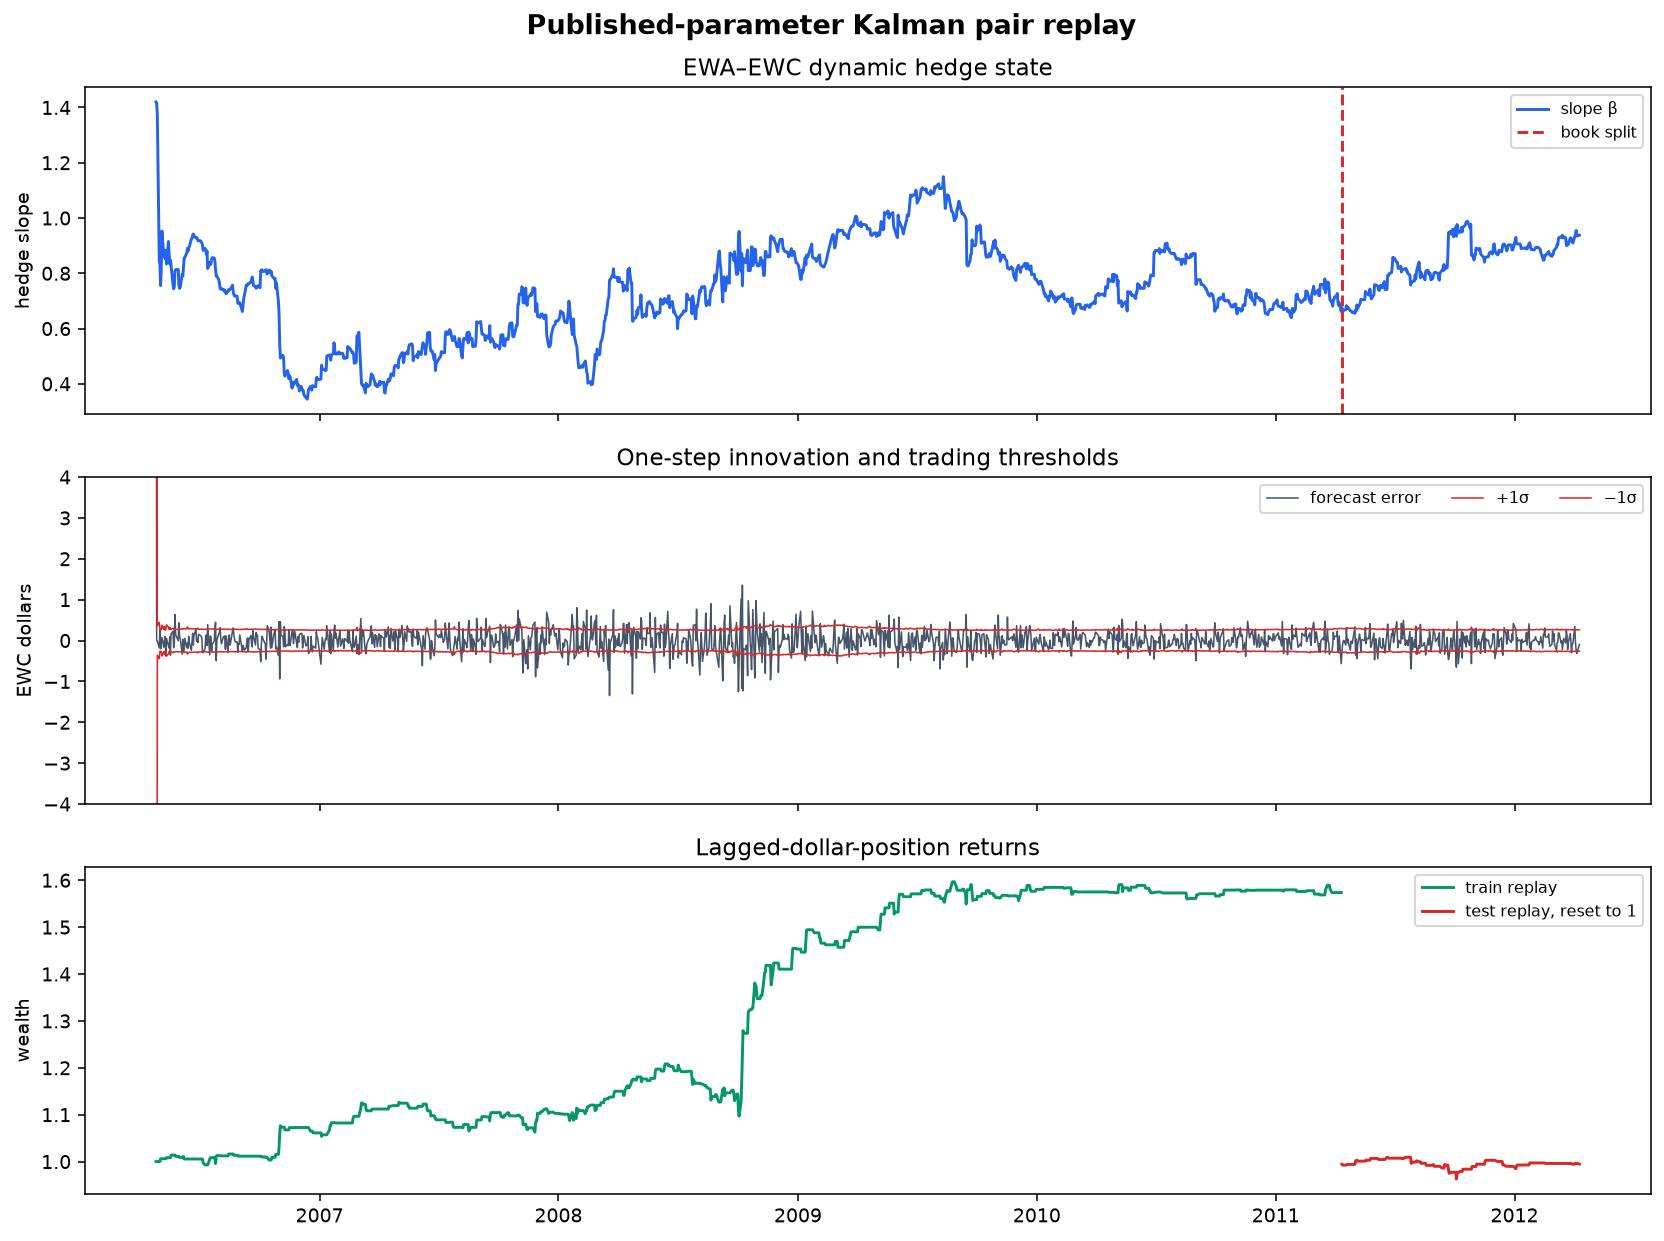

In [12]:
pair = results["pair_kalman"]
display(pd.DataFrame({
    "train replay": pair.metadata["train_performance"],
    "test": pair.performance.__dict__,
}).loc[["annual_return", "sharpe", "maximum_drawdown"]])
print("state changes:", pair.metadata["state_changes"])
assert pair.metadata["process_loading"] == [[-0.01015, 0.02114], [0.40606, -0.32381]]
show_figure(create_pair_figure(data, results))

## 14. Look-ahead, survivorship, selection bias

원본 look-ahead를 그대로 재현하는 경로는 버리지 않되 빨간 라벨로 격리한다.
train-only 수정본과 나란히 둬야 왜 숫자가 달라졌는지 설명할 수 있다. hardware
close의 다섯 종목은 책의 시점별 CRSP/Compustat universe가 아니므로 survivorship와
selection bias를 독립적으로 제거했다고 주장할 수 없다. AR/VAR 차수, 종목군,
Kalman threshold를 같은 test 결과를 보며 반복 선택하면 표본 외가 다시 학습자료가
된다.

## 15. 위험지표와 백테스트 범위

CAGR과 Sharpe만으로 충분하지 않아 maximum drawdown과 drawdown duration도 저장한다.
거래비용은 AUD의 관측 spread와 일봉 편도 2bps 민감도이며 borrow fee와 market
impact는 빠져 있다. AR/VAR/페어 결과는 명시한 시차의 백테스트지만, HP/wavelet
설명·ARIMA 등식·state equation 설명은 백테스트가 아님을 구분한다. 서로 다른
기간의 train과 test 곡선을 이어붙여 하나의 지속적 wealth처럼 보이지 않는다.

## 16. 자동 검증

검증은 책과의 독립/경험 비교와 계산 계약 invariant를 분리한다. checksum,
AR 계수, BIC, 책 수익률, Table 3.1은 전자다. 원본 누수 문자열, train/full 차이,
비용 단조성, sector neutrality, VEC identity, Kalman 고정계수, 순차 split은 후자다.
assert가 실패하면 리포트와 metrics를 성공 산출물로 남기지 않는다.

In [13]:
checks = verify_results(data, results)
summary = verification_summary(checks)
display(pd.Series(checks).to_frame("passed"))
display(pd.Series(summary).drop("classification").to_frame("count"))
assert all(checks.values())
assert summary["total"] == 15 and summary["passed"] == 15

,passed
archive_manifest_matches,True
aud_ar1_phi_matches_source,True
btc_ar1_phi_matches_source,True
ar_bic_selects_book_lag_10,True
ar10_full_fit_matches_book_output,True
arma25_replay_matches_book_output,True
var_close_bic_selects_lag_1,True
ar10_coefficients_match_table_31,True
source_ar10_lookahead_detected,True
train_only_ar10_differs_from_source_fit,True


,count
total,15
passed,15
independent_or_empirical,8
contract_invariant,7


## 17. 결론

좋은 시계열 실험은 예측모형 이름보다 정보 경계를 먼저 고정한다. 이 장에서는
책 AR/ARMA 숫자를 재현하면서도 AR(10)의 전체표본 적합을 발견했고, train-only
수정 뒤에도 spread가 분봉 알파를 없앤다는 점을 확인했다. VAR/VEC와 Kalman은
필요 입력이 없는 부분을 정확 재현으로 포장하지 않고 공식 close 적응과 계수
replay로 제한했다.

다른 책과 프로젝트에도 적용할 체크리스트는 같다. 원본 archive와 checksum을
고정하고, 수식마다 구현 함수를 연결하며, fit/forecast/position/P&L의 시차를
assert하고, 비용 전후를 함께 표시하며, exact·approximate·adaptation·unavailable을
명시한다. 마지막으로 test 결과를 보고 모형을 다시 고르면 새 test가 필요하다.